# 1. Environment setup


In [1]:


import sys
import subprocess
import pkgutil
import warnings
warnings.filterwarnings("ignore")

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "imblearn": "imbalanced-learn",
    "shap": "shap",
    "lime": "lime",
    "joblib": "joblib"
}

def install_if_missing(import_name, pip_name):
    if pkgutil.find_loader(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"Available: {pip_name}")

for import_name, pip_name in REQUIRED_PACKAGES.items():
    install_if_missing(import_name, pip_name)

print("\nEnvironment is ready.")

Available: numpy
Available: pandas
Available: matplotlib
Available: seaborn
Available: scikit-learn
Available: imbalanced-learn
Available: shap
Available: lime
Available: joblib

Environment is ready.


# 2. Imports and global configuration

In [2]:
import os
import re
import glob
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.calibration import calibration_curve

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import TomekLinks, InstanceHardnessThreshold
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
from lime.lime_tabular import LimeTabularExplainer

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)


CUSTOM_DATA_PATH = "/kaggle/input/datasets/mohameddarweish/cardiovascular-diseases-processed"


TARGET_COLUMN = "CARDIO_DISEASE"

FAST_MODE = False

RUN_FULL_BALANCING_GRID = False

MAIN_BALANCING_STRATEGY = "RO+TL"
MAIN_MODEL_NAME = "ExtraTrees"

OUTPUT_DIR = Path("talukder_2025_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration loaded.")
print(f"FAST_MODE = {FAST_MODE}")
print(f"RUN_FULL_BALANCING_GRID = {RUN_FULL_BALANCING_GRID}")
print(f"Outputs will be saved to: {OUTPUT_DIR.resolve()}")

Configuration loaded.
FAST_MODE = False
RUN_FULL_BALANCING_GRID = False
Outputs will be saved to: /kaggle/working/talukder_2025_outputs


In [5]:

# ============================================================
# 3. Dataset loading and utility helpers
# ============================================================

def normalize_name(name):
    """
    Standardize column names for safer downstream processing.
    """
    name = str(name).strip().lower()
    name = re.sub(r"[^a-zA-Z0-9]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name.upper()


def find_csv_files(base_path):
    """
    Recursively search for CSV files inside a Kaggle dataset directory.
    """
    if base_path is None:
        return []

    base_path = Path(base_path)

    if base_path.is_file() and base_path.suffix.lower() == ".csv":
        return [str(base_path)]

    if not base_path.exists():
        return []

    return sorted([str(p) for p in base_path.rglob("*.csv")])


def load_dataset(custom_path=None):
    """
    Load dataset from Kaggle input directory or a direct CSV path.
    """
    candidate_paths = []

    if custom_path:
        candidate_paths.append(custom_path)

    candidate_paths.extend([
        "/kaggle/input",
        "../input"
    ])

    discovered_csvs = []

    for path in candidate_paths:
        discovered_csvs.extend(find_csv_files(path))

    discovered_csvs = list(dict.fromkeys(discovered_csvs))

    if len(discovered_csvs) == 0:
        raise FileNotFoundError(
            "No CSV dataset was found. Please verify CUSTOM_DATA_PATH."
        )

    print("Detected CSV files:")
    for idx, csv_path in enumerate(discovered_csvs, start=1):
        print(f"{idx}. {csv_path}")

    DATA_PATH = discovered_csvs[0]
    print(f"\nUsing dataset: {DATA_PATH}")

    df_loaded = pd.read_csv(DATA_PATH)

    return df_loaded, DATA_PATH


# Load dataset
df_raw, DATA_PATH = load_dataset(CUSTOM_DATA_PATH)

print("\nDataset loaded successfully.")
print(f"Dataset shape: {df_raw.shape}")
display(df_raw.head())


Detected CSV files:
1. /kaggle/input/datasets/mohameddarweish/cardiovascular-diseases-processed/cardiovascular_diseases_processed.csv
2. ../input/datasets/mohameddarweish/cardiovascular-diseases-processed/cardiovascular_diseases_processed.csv

Using dataset: /kaggle/input/datasets/mohameddarweish/cardiovascular-diseases-processed/cardiovascular_diseases_processed.csv

Dataset loaded successfully.
Dataset shape: (68783, 12)


,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE
0,50,2,168,62,110,80,1,1,0,0,1,0
1,55,1,156,85,140,90,3,1,0,0,1,1
2,52,1,165,64,130,70,3,1,0,0,0,1
3,48,2,169,82,150,100,1,1,0,0,1,1
4,48,1,156,56,100,60,1,1,0,0,0,0


# 4. Column cleaning and target detection

In [6]:
df = df_raw.copy()
original_columns = df.columns.tolist()

df.columns = [normalize_name(c) for c in df.columns]
print("Column names were standardized.")
display(pd.DataFrame({"Original": original_columns, "Cleaned": df.columns.tolist()}))

target_candidates = [
    TARGET_COLUMN,
    "CARDIO_DISEASE", "CARDIO", "TARGET", "OUTPUT",
    "TENYEARCHD", "HEARTDISEASE", "HEART_DISEASE", "DISEASE", "NUM"
]
target_candidates = [normalize_name(c) for c in target_candidates]

TARGET_COLUMN_CLEAN = None
for c in target_candidates:
    if c in df.columns:
        TARGET_COLUMN_CLEAN = c
        break

if TARGET_COLUMN_CLEAN is None:
    # Conservative fallback: use the last column and make the choice explicit.
    TARGET_COLUMN_CLEAN = df.columns[-1]
    print(
        f"WARNING: Could not auto-detect the target column. "
        f"Using the last column as target: {TARGET_COLUMN_CLEAN}"
    )

print(f"\nTarget column used: {TARGET_COLUMN_CLEAN}")
print("\nTarget distribution:")
display(df[TARGET_COLUMN_CLEAN].value_counts(dropna=False).to_frame("count"))

Column names were standardized.


,Original,Cleaned
0,AGE,AGE
1,GENDER,GENDER
2,HEIGHT,HEIGHT
3,WEIGHT,WEIGHT
4,AP_HIGH,AP_HIGH
5,AP_LOW,AP_LOW
6,CHOLESTEROL,CHOLESTEROL
7,GLUCOSE,GLUCOSE
8,SMOKE,SMOKE
9,ALCOHOL,ALCOHOL



Target column used: CARDIO_DISEASE

Target distribution:


,count
CARDIO_DISEASE,
0,34742
1,34041


## 4. Exploratory Data Analysis (EDA)


In [7]:

print("=" * 90)
print("DATASET OVERVIEW")
print("=" * 90)

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

missing_df = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": 100 * df.isna().mean()
}).sort_values("missing_percent", ascending=False)

print("\nMissing values:")
display(missing_df)

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

DATASET OVERVIEW
Shape: (68783, 12)
Rows: 68,783
Columns: 12
Duplicate rows: 3,820

Data types:


,dtype
AGE,int64
GENDER,int64
HEIGHT,int64
WEIGHT,int64
AP_HIGH,int64
AP_LOW,int64
CHOLESTEROL,int64
GLUCOSE,int64
SMOKE,int64
ALCOHOL,int64



Missing values:


,missing_count,missing_percent
AGE,0,0.0
GENDER,0,0.0
HEIGHT,0,0.0
WEIGHT,0,0.0
AP_HIGH,0,0.0
AP_LOW,0,0.0
CHOLESTEROL,0,0.0
GLUCOSE,0,0.0
SMOKE,0,0.0
ALCOHOL,0,0.0



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
AGE,68783.0,53.326781,6.768163,30.0,48.0,54.0,58.0,65.0
GENDER,68783.0,1.348749,0.476578,1.0,1.0,1.0,2.0,2.0
HEIGHT,68783.0,164.361252,8.184850,55.0,159.0,165.0,170.0,250.0
WEIGHT,68783.0,74.121934,14.331392,11.0,65.0,72.0,82.0,200.0
AP_HIGH,68783.0,126.614585,16.763763,60.0,120.0,120.0,140.0,240.0
AP_LOW,68783.0,81.381591,9.676679,40.0,80.0,80.0,90.0,190.0
CHOLESTEROL,68783.0,1.364727,0.678976,1.0,1.0,1.0,2.0,3.0
GLUCOSE,68783.0,1.225986,0.571961,1.0,1.0,1.0,1.0,3.0
SMOKE,68783.0,0.088001,0.283299,0.0,0.0,0.0,0.0,1.0
ALCOHOL,68783.0,0.053632,0.225293,0.0,0.0,0.0,0.0,1.0


# 6. EDA visualizations


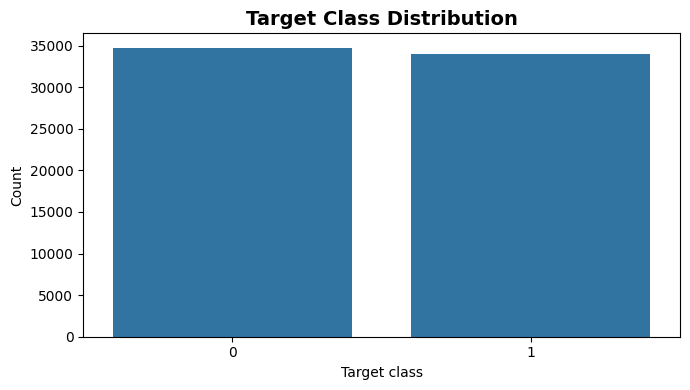

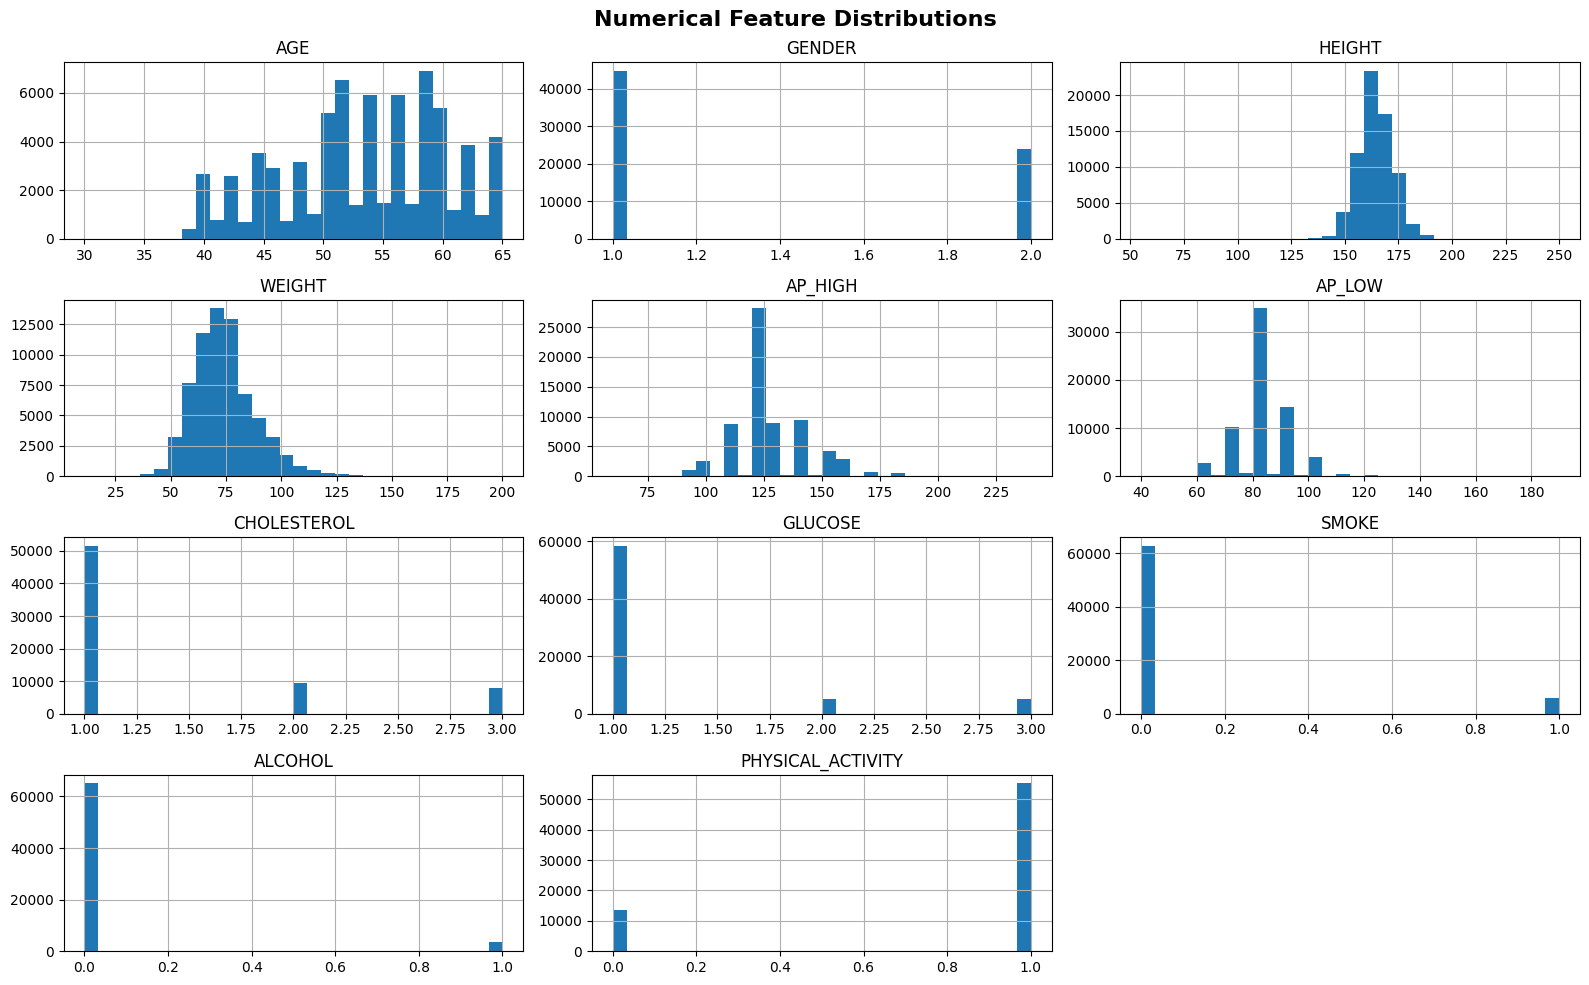

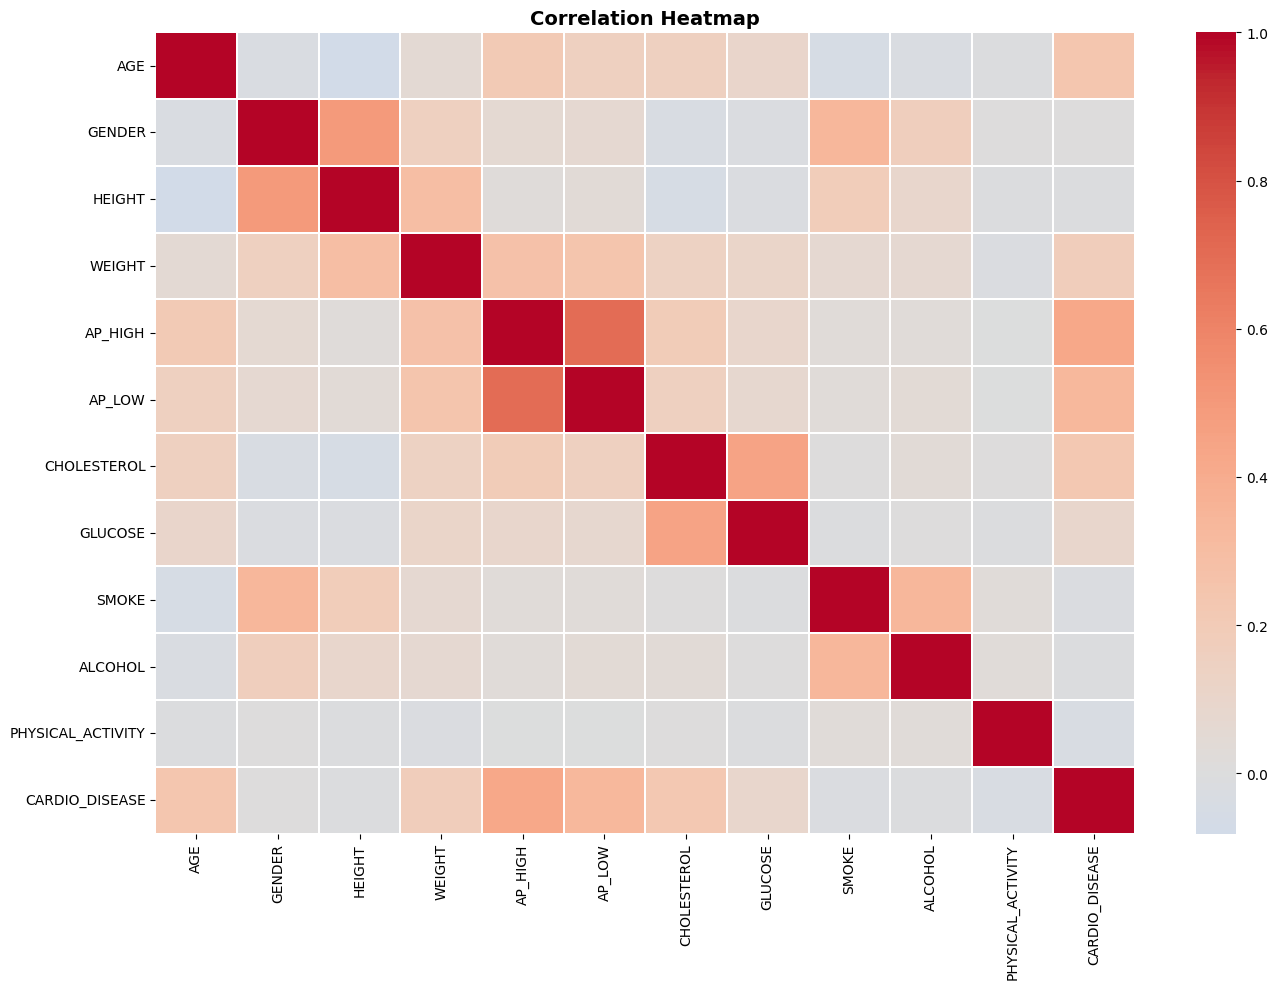


Top absolute correlations with target:


,absolute_correlation_with_target
AP_HIGH,0.425109
AP_LOW,0.335067
AGE,0.239133
CHOLESTEROL,0.221517
WEIGHT,0.179680
GLUCOSE,0.090100
PHYSICAL_ACTIVITY,0.037197
SMOKE,0.016285
HEIGHT,0.010752
ALCOHOL,0.008222


In [8]:
plt.figure(figsize=(7, 4))
sns.countplot(x=TARGET_COLUMN_CLEAN, data=df)
plt.title("Target Class Distribution", fontsize=14, weight="bold")
plt.xlabel("Target class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "target_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

num_cols_for_eda = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COLUMN_CLEAN in num_cols_for_eda:
    num_cols_for_eda.remove(TARGET_COLUMN_CLEAN)

if len(num_cols_for_eda) > 0:
    sample_features = num_cols_for_eda[:12]
    df[sample_features].hist(figsize=(16, 10), bins=30)
    plt.suptitle("Numerical Feature Distributions", fontsize=16, weight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "numeric_feature_distributions.png", dpi=200, bbox_inches="tight")
    plt.show()

if len(num_cols_for_eda) >= 2:
    corr_cols = num_cols_for_eda[:20] + [TARGET_COLUMN_CLEAN]
    corr = df[corr_cols].corr(numeric_only=True)
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
    plt.title("Correlation Heatmap", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=200, bbox_inches="tight")
    plt.show()

    if TARGET_COLUMN_CLEAN in corr.columns:
        print("\nTop absolute correlations with target:")
        target_corr = corr[TARGET_COLUMN_CLEAN].drop(TARGET_COLUMN_CLEAN).abs().sort_values(ascending=False)
        display(target_corr.head(15).to_frame("absolute_correlation_with_target"))

The original Talukder paper emphasizes improving model performance through a hybrid pipeline.  
For our dataset, this notebook adds clinically meaningful engineered features **only when the required columns exist**.

Examples:
- **BMI** from height and weight
- **Pulse pressure** from systolic and diastolic blood pressure
- **Blood pressure ratio**
- **Age-risk interactions**

# 7. Feature engineering

In [9]:
df_fe = df.copy()

created_features = []

def add_feature_safe(name, values):
    if name not in df_fe.columns:
        df_fe[name] = values
        created_features.append(name)

colset = set(df_fe.columns)

if "AGE" in colset:
    if pd.api.types.is_numeric_dtype(df_fe["AGE"]) and df_fe["AGE"].median() > 130:
        add_feature_safe("AGE_YEARS", df_fe["AGE"] / 365.25)
    else:
        add_feature_safe("AGE_YEARS", df_fe["AGE"])

if {"HEIGHT", "WEIGHT"}.issubset(colset):
    height_m = df_fe["HEIGHT"] / 100.0
    bmi = df_fe["WEIGHT"] / (height_m.replace(0, np.nan) ** 2)
    add_feature_safe("BMI", bmi.replace([np.inf, -np.inf], np.nan))

systolic_candidates = ["AP_HIGH", "SYSTOLIC", "SYSBP", "TRESTBPS"]
diastolic_candidates = ["AP_LOW", "DIASTOLIC", "DIABP"]

systolic_col = next((c for c in systolic_candidates if c in colset), None)
diastolic_col = next((c for c in diastolic_candidates if c in colset), None)

if systolic_col and diastolic_col:
    add_feature_safe("PULSE_PRESSURE", df_fe[systolic_col] - df_fe[diastolic_col])
    add_feature_safe("BP_RATIO", df_fe[systolic_col] / (df_fe[diastolic_col].replace(0, np.nan) + 1e-6))

if "AGE_YEARS" in df_fe.columns and "BMI" in df_fe.columns:
    add_feature_safe("AGE_BMI_INTERACTION", df_fe["AGE_YEARS"] * df_fe["BMI"])

if systolic_col and "CHOLESTEROL" in colset:
    add_feature_safe("BP_CHOLESTEROL_INTERACTION", df_fe[systolic_col] * df_fe["CHOLESTEROL"])

print(f"Created engineered features: {created_features if created_features else 'No extra features were created because the required columns were not found.'}")
print(f"Shape after feature engineering: {df_fe.shape}")

display(df_fe.head())

Created engineered features: ['AGE_YEARS', 'BMI', 'PULSE_PRESSURE', 'BP_RATIO', 'AGE_BMI_INTERACTION', 'BP_CHOLESTEROL_INTERACTION']
Shape after feature engineering: (68783, 18)


,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE,AGE_YEARS,BMI,PULSE_PRESSURE,BP_RATIO,AGE_BMI_INTERACTION,BP_CHOLESTEROL_INTERACTION
0,50,2,168,62,110,80,1,1,0,0,1,0,50,21.967120,30,1.375000,1098.356009,110
1,55,1,156,85,140,90,3,1,0,0,1,1,55,34.927679,50,1.555556,1921.022354,420
2,52,1,165,64,130,70,3,1,0,0,0,1,52,23.507805,60,1.857143,1222.405877,390
3,48,2,169,82,150,100,1,1,0,0,1,1,48,28.710479,50,1.500000,1378.103008,150
4,48,1,156,56,100,60,1,1,0,0,0,0,48,23.011177,40,1.666667,1104.536489,100


## 6. Train/test split and preprocessing

In [10]:
# ============================================================
# 8. Prepare X/y, clean target, split data
# ============================================================

df_model = df_fe.copy()

df_model = df_model.dropna(subset=[TARGET_COLUMN_CLEAN]).reset_index(drop=True)

id_like_cols = [
    c for c in df_model.columns
    if c != TARGET_COLUMN_CLEAN and c in {"ID", "INDEX", "PATIENT_ID", "SUBJECT_ID", "ROW_ID"}
]

if id_like_cols:
    print(f"Dropping ID-like columns: {id_like_cols}")
    df_model = df_model.drop(columns=id_like_cols)

X = df_model.drop(columns=[TARGET_COLUMN_CLEAN])
y_raw = df_model[TARGET_COLUMN_CLEAN]

label_encoder = LabelEncoder()
y = pd.Series(label_encoder.fit_transform(y_raw), name=TARGET_COLUMN_CLEAN)

class_names = [str(c) for c in label_encoder.classes_]
n_classes = len(class_names)

print(f"Number of classes: {n_classes}")
print(f"Class names: {class_names}")

if n_classes < 2:
    raise ValueError("The target column has fewer than two classes. Classification cannot be trained.")

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train shape: {X_train_raw.shape}")
print(f"Test shape : {X_test_raw.shape}")

print("\nTrain class distribution:")
display(y_train.value_counts().sort_index().to_frame("count"))

print("\nTest class distribution:")
display(y_test.value_counts().sort_index().to_frame("count"))

Number of classes: 2
Class names: ['0', '1']
Train shape: (55026, 17)
Test shape : (13757, 17)

Train class distribution:


,count
CARDIO_DISEASE,
0,27793
1,27233



Test class distribution:


,count
CARDIO_DISEASE,
0,6949
1,6808


# 9. Preprocessing pipeline


In [11]:
numeric_features = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train_raw.columns if c not in numeric_features]

print(f"Numerical features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out()
feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

X_train_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train_raw.index)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test_raw.index)

print(f"Processed train shape: {X_train_df.shape}")
print(f"Processed test shape : {X_test_df.shape}")
display(X_train_df.head())

Numerical features: 17
Categorical features: 0
Processed train shape: (55026, 17)
Processed test shape : (13757, 17)


,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,AGE_YEARS,BMI,PULSE_PRESSURE,BP_RATIO,AGE_BMI_INTERACTION,BP_CHOLESTEROL_INTERACTION
61337,0.545056,-0.734178,-1.763565,-1.546540,-0.988375,-1.172671,0.934910,-0.394439,-0.310515,-0.23724,0.495532,0.545056,-0.734130,-0.427286,0.070222,-0.401415,0.460699
24795,1.579568,-0.734178,0.196457,0.684614,0.202524,-0.142404,-0.537959,-0.394439,-0.310515,-0.23724,0.495532,1.579568,0.490159,0.391802,0.419299,1.251687,-0.462621
5578,-0.489455,1.362068,0.931465,0.545167,-0.988375,-0.142404,-0.537959,-0.394439,-0.310515,-0.23724,0.495532,-0.489455,0.030869,-1.246373,-1.209725,-0.222562,-0.667803
8198,-1.967329,-0.734178,0.441460,0.196549,-0.988375,-0.142404,-0.537959,-0.394439,-0.310515,-0.23724,0.495532,-1.967329,-0.041526,-1.246373,-1.209725,-0.991226,-0.667803
55351,0.545056,1.362068,-0.661052,-0.709857,-0.392926,-0.142404,-0.537959,-0.394439,-0.310515,-0.23724,0.495532,0.545056,-0.368062,-0.427286,-0.395213,-0.073594,-0.565212


# Talukder-style hybrid balancing strategies

The paper's HXAI-ML framework combines data balancing with ML models.  
This notebook implements the main paper direction with:

- **RO:** Random Oversampling
- **SMOTE:** Synthetic Minority Oversampling Technique
- **RO + TL:** Random Oversampling followed by Tomek Links
- **SMOTE + TL:** SMOTE-Tomek
- Optional slower variants:
  - **RO + IHT**
  - **SMOTE + IHT**

The final selected model uses **RO + TL + Extra Trees Classifier** by default.

# 10. Balancing strategy definitions

In [12]:
def make_smote():
    counts = pd.Series(y_train).value_counts()
    min_count = counts.min()
    if min_count <= 1:
        raise ValueError("SMOTE cannot be used because at least one class has <= 1 sample.")
    k_neighbors = max(1, min(5, int(min_count) - 1))
    return SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)

def make_balancers():
    balancers = {
        "None": None,
        "RO": RandomOverSampler(random_state=RANDOM_STATE),
        "SMOTE": make_smote(),
        "RO+TL": ImbPipeline(steps=[
            ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
            ("tl", TomekLinks())
        ]),
        "SMOTE+TL": SMOTETomek(random_state=RANDOM_STATE, smote=make_smote(), tomek=TomekLinks())
    }

    if RUN_FULL_BALANCING_GRID:
        iht_estimator = RandomForestClassifier(
            n_estimators=50 if FAST_MODE else 100,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced"
        )
        balancers["RO+IHT"] = ImbPipeline(steps=[
            ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
            ("iht", InstanceHardnessThreshold(
                estimator=iht_estimator,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])
        balancers["SMOTE+IHT"] = ImbPipeline(steps=[
            ("smote", make_smote()),
            ("iht", InstanceHardnessThreshold(
                estimator=iht_estimator,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

    return balancers

balancers = make_balancers()

print("Available balancing strategies:")
for name in balancers.keys():
    print(f"- {name}")

def apply_balancer(strategy_name, X_data, y_data):
    balancer = balancers[strategy_name]
    if balancer is None:
        return X_data.copy(), y_data.copy()

    X_res, y_res = balancer.fit_resample(X_data, y_data)
    X_res = pd.DataFrame(X_res, columns=X_data.columns)
    y_res = pd.Series(y_res, name=y_data.name)
    return X_res, y_res

X_train_main, y_train_main = apply_balancer(MAIN_BALANCING_STRATEGY, X_train_df, y_train.reset_index(drop=True))

print(f"\nMain balancing strategy: {MAIN_BALANCING_STRATEGY}")
print(f"Before balancing: {X_train_df.shape}")
print(f"After balancing : {X_train_main.shape}")

print("\nClass distribution after main balancing:")
display(y_train_main.value_counts().sort_index().to_frame("count"))

Available balancing strategies:
- None
- RO
- SMOTE
- RO+TL
- SMOTE+TL

Main balancing strategy: RO+TL
Before balancing: (55026, 17)
After balancing : (51308, 17)

Class distribution after main balancing:


,count
CARDIO_DISEASE,
0,27793
1,23515


# 11. Define models
The paper reports that the hybrid balancing + **Extra Trees Classifier** combination gives strong performance.  
For a professional final project notebook, we still compare against several relevant models.

In [13]:
def make_models():
    models = {
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=300 if not FAST_MODE else 100,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight=None
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300 if not FAST_MODE else 100,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight=None
        ),
        "DecisionTree": DecisionTreeClassifier(
            max_depth=None,
            random_state=RANDOM_STATE,
            class_weight=None
        ),
        "GradientBoosting": GradientBoostingClassifier(
            n_estimators=150 if not FAST_MODE else 50,
            learning_rate=0.05,
            max_depth=3,
            random_state=RANDOM_STATE
        ),
        "KNN": KNeighborsClassifier(
            n_neighbors=7,
            weights="distance"
        ),
        "LogisticRegression": LogisticRegression(
            max_iter=3000,
            solver="lbfgs",
            multi_class="auto",
            n_jobs=-1
        )
    }
    return models

models = make_models()
print("Models:")
for name in models.keys():
    print(f"- {name}")

Models:
- ExtraTrees
- RandomForest
- DecisionTree
- GradientBoosting
- KNN
- LogisticRegression


# 12. Evaluation helpers

In [14]:
def predict_scores(model, X_eval):
    y_pred = model.predict(X_eval)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_eval)
    elif hasattr(model, "decision_function"):
        decision = model.decision_function(X_eval)
        if decision.ndim == 1:
            # Convert decision scores to pseudo probabilities for binary use.
            p1 = 1 / (1 + np.exp(-decision))
            y_proba = np.vstack([1 - p1, p1]).T
        else:
            exp_scores = np.exp(decision - decision.max(axis=1, keepdims=True))
            y_proba = exp_scores / exp_scores.sum(axis=1, keepdims=True)
    else:
        y_proba = None

    return y_pred, y_proba

def compute_metrics(y_true, y_pred, y_proba=None, prefix=""):
    avg = "binary" if n_classes == 2 else "macro"

    metrics = {
        f"{prefix}Accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}Precision": precision_score(y_true, y_pred, average=avg, zero_division=0),
        f"{prefix}Recall": recall_score(y_true, y_pred, average=avg, zero_division=0),
        f"{prefix}F1": f1_score(y_true, y_pred, average=avg, zero_division=0)
    }

    if y_proba is not None:
        try:
            if n_classes == 2:
                metrics[f"{prefix}ROC_AUC"] = roc_auc_score(y_true, y_proba[:, 1])
                metrics[f"{prefix}PR_AUC"] = average_precision_score(y_true, y_proba[:, 1])
            else:
                metrics[f"{prefix}ROC_AUC_OVR"] = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
                metrics[f"{prefix}PR_AUC_Macro"] = average_precision_score(pd.get_dummies(y_true), y_proba, average="macro")
        except Exception as e:
            print(f"Could not compute probability-based metrics: {e}")

    # Binary specificity
    if n_classes == 2:
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            metrics[f"{prefix}Specificity"] = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return metrics

def evaluate_model(model, X_eval, y_eval):
    y_pred, y_proba = predict_scores(model, X_eval)
    return compute_metrics(y_eval, y_pred, y_proba), y_pred, y_proba

# 13. Compact grid: balancing strategy x model comparison

In [15]:
if FAST_MODE:
    grid_balancers = [MAIN_BALANCING_STRATEGY]
    grid_model_names = ["ExtraTrees", "RandomForest"]
else:
    grid_balancers = ["None", "RO", "SMOTE", "RO+TL", "SMOTE+TL"]
    if RUN_FULL_BALANCING_GRID:
        grid_balancers += ["RO+IHT", "SMOTE+IHT"]
    grid_model_names = ["ExtraTrees", "RandomForest", "DecisionTree", "GradientBoosting", "KNN", "LogisticRegression"]

comparison_rows = []
trained_grid_models = {}

start_all = time.time()

for bal_name in grid_balancers:
    print("\n" + "=" * 90)
    print(f"Balancing strategy: {bal_name}")
    print("=" * 90)

    try:
        X_bal, y_bal = apply_balancer(bal_name, X_train_df.reset_index(drop=True), y_train.reset_index(drop=True))
        print(f"Balanced shape: {X_bal.shape}; class counts: {dict(pd.Series(y_bal).value_counts().sort_index())}")
    except Exception as e:
        print(f"Skipping {bal_name} due to balancing error: {e}")
        continue

    for model_name in grid_model_names:
        model = make_models()[model_name]
        print(f"Training {model_name} with {bal_name}...", end=" ")

        t0 = time.time()
        try:
            model.fit(X_bal, y_bal)
            training_time = time.time() - t0

            metrics, y_pred_tmp, y_proba_tmp = evaluate_model(model, X_test_df, y_test)

            row = {
                "Balancing": bal_name,
                "Model": model_name,
                "Training_Time_Seconds": training_time,
                **metrics
            }
            comparison_rows.append(row)
            trained_grid_models[(bal_name, model_name)] = model

            print(f"done | F1={metrics.get('F1', np.nan):.4f} | Acc={metrics.get('Accuracy', np.nan):.4f}")
        except Exception as e:
            print(f"failed: {e}")

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(
    by=["F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)

print(f"\nTotal grid time: {(time.time() - start_all):.2f} seconds")
print("\nModel comparison results:")
display(comparison_df)

comparison_df.to_csv(OUTPUT_DIR / "talukder_model_comparison_results.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'talukder_model_comparison_results.csv'}")


Balancing strategy: None
Balanced shape: (55026, 17); class counts: {0: np.int64(27793), 1: np.int64(27233)}
Training ExtraTrees with None... done | F1=0.6839 | Acc=0.6890
Training RandomForest with None... done | F1=0.6990 | Acc=0.7039
Training DecisionTree with None... done | F1=0.6271 | Acc=0.6365
Training GradientBoosting with None... done | F1=0.7158 | Acc=0.7317
Training KNN with None... done | F1=0.6895 | Acc=0.6951
Training LogisticRegression with None... done | F1=0.7075 | Acc=0.7227

Balancing strategy: RO
Balanced shape: (55586, 17); class counts: {0: np.int64(27793), 1: np.int64(27793)}
Training ExtraTrees with RO... done | F1=0.6822 | Acc=0.6877
Training RandomForest with RO... done | F1=0.6982 | Acc=0.7034
Training DecisionTree with RO... done | F1=0.6243 | Acc=0.6332
Training GradientBoosting with RO... done | F1=0.7161 | Acc=0.7304
Training KNN with RO... done | F1=0.6900 | Acc=0.6944
Training LogisticRegression with RO... done | F1=0.7093 | Acc=0.7231

Balancing strat

,Balancing,Model,Training_Time_Seconds,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Specificity
0,RO,GradientBoosting,12.837638,0.730392,0.747722,0.686986,0.716068,0.799056,0.782875,0.772917
1,None,GradientBoosting,12.060406,0.731700,0.752225,0.682726,0.715793,0.799050,0.782077,0.779681
2,SMOTE,GradientBoosting,12.568680,0.729738,0.747596,0.685223,0.715052,0.798999,0.781902,0.773349
3,SMOTE,LogisticRegression,1.149027,0.723195,0.738322,0.682579,0.709357,0.787575,0.763838,0.762987
4,RO,LogisticRegression,1.153029,0.723123,0.738129,0.682726,0.709348,0.787573,0.763869,0.762700
5,None,LogisticRegression,1.603056,0.722687,0.740093,0.677585,0.707461,0.787586,0.763883,0.766873
6,SMOTE,RandomForest,12.244492,0.703787,0.702895,0.695358,0.699107,0.764309,0.741824,0.712045
7,RO+TL,GradientBoosting,11.443845,0.729083,0.776224,0.635870,0.699071,0.798129,0.781313,0.820406
8,None,RandomForest,11.653218,0.703860,0.703241,0.694771,0.698980,0.764583,0.743645,0.712764
9,SMOTE+TL,GradientBoosting,11.826252,0.729011,0.777477,0.633813,0.698333,0.797842,0.780172,0.822277


Saved: talukder_2025_outputs/talukder_model_comparison_results.csv


# 14. Main model training with optional hyperparameter tuning

It uses the best paper-style combination: **Random Oversampling + Tomek Links + Extra Trees Classifier**.

In [16]:
X_train_main, y_train_main = apply_balancer(
    MAIN_BALANCING_STRATEGY,
    X_train_df.reset_index(drop=True),
    y_train.reset_index(drop=True)
)

base_etc = ExtraTreesClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_distributions = {
    "n_estimators": [200, 300, 500] if not FAST_MODE else [100, 200],
    "max_depth": [None, 8, 12, 16, 24],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.6, 0.8, None],
    "bootstrap": [False, True]
}

scoring_metric = "roc_auc" if n_classes == 2 else "f1_macro"
cv = StratifiedKFold(n_splits=5 if not FAST_MODE else 3, shuffle=True, random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    estimator=base_etc,
    param_distributions=param_distributions,
    n_iter=20 if not FAST_MODE else 5,
    scoring=scoring_metric,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

print("Starting hyperparameter tuning for Extra Trees...")
t0 = time.time()
random_search.fit(X_train_main, y_train_main)
tuning_time = time.time() - t0

best_model = random_search.best_estimator_

print("\nBest parameters:")
print(random_search.best_params_)
print(f"Best CV score ({scoring_metric}): {random_search.best_score_:.4f}")
print(f"Tuning time: {tuning_time:.2f} seconds")

Starting hyperparameter tuning for Extra Trees...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 24, 'bootstrap': False}
Best CV score (roc_auc): 0.8294
Tuning time: 527.23 seconds


# 15. Cross-validation of tuned main model on balanced training data

In [17]:
cv_scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

if n_classes == 2:
    cv_scoring["roc_auc"] = "roc_auc"

cv_results = cross_validate(
    best_model,
    X_train_main,
    y_train_main,
    scoring=cv_scoring,
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    metric.replace("test_", ""): [np.mean(values), np.std(values)]
    for metric, values in cv_results.items()
    if metric.startswith("test_")
}, index=["mean", "std"]).T

print("Cross-validation summary:")
display(cv_summary)

cv_summary.to_csv(OUTPUT_DIR / "main_model_cross_validation_summary.csv")

Cross-validation summary:


,mean,std
accuracy,0.764189,0.005566
precision_macro,0.764735,0.005511
recall_macro,0.758926,0.005798
f1_macro,0.760352,0.005801
roc_auc,0.829376,0.004662


# 16. Final evaluation

In [18]:
final_metrics, y_pred, y_proba = evaluate_model(best_model, X_test_df, y_test)

final_metrics_df = pd.DataFrame([final_metrics]).T.rename(columns={0: "value"})
print("Final hold-out test metrics:")
display(final_metrics_df)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

final_metrics_df.to_csv(OUTPUT_DIR / "main_model_final_metrics.csv")
with open(OUTPUT_DIR / "classification_report.txt", "w") as f:
    f.write(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

print(f"\nSaved final metrics to: {OUTPUT_DIR / 'main_model_final_metrics.csv'}")

Final hold-out test metrics:


,value
Accuracy,0.723850
Precision,0.765954
Recall,0.636457
F1,0.695227
ROC_AUC,0.789707
PR_AUC,0.772468
Specificity,0.809469



Classification report:
              precision    recall  f1-score   support

           0       0.69      0.81      0.75      6949
           1       0.77      0.64      0.70      6808

    accuracy                           0.72     13757
   macro avg       0.73      0.72      0.72     13757
weighted avg       0.73      0.72      0.72     13757


Saved final metrics to: talukder_2025_outputs/main_model_final_metrics.csv


# 17. Confusion matrix

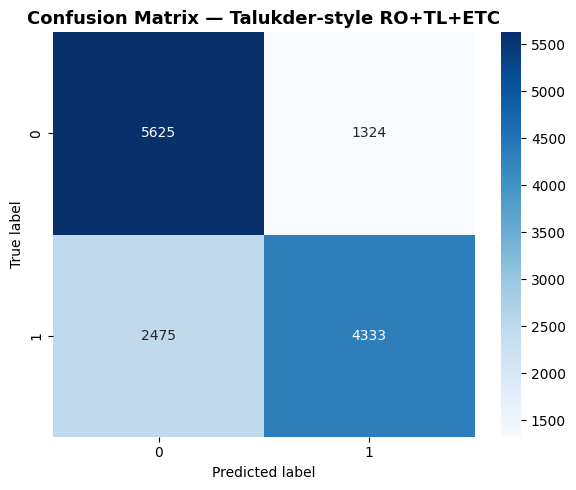

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix — Talukder-style RO+TL+ETC", fontsize=13, weight="bold")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "main_model_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

# 18. ROC and Precision-Recall curves

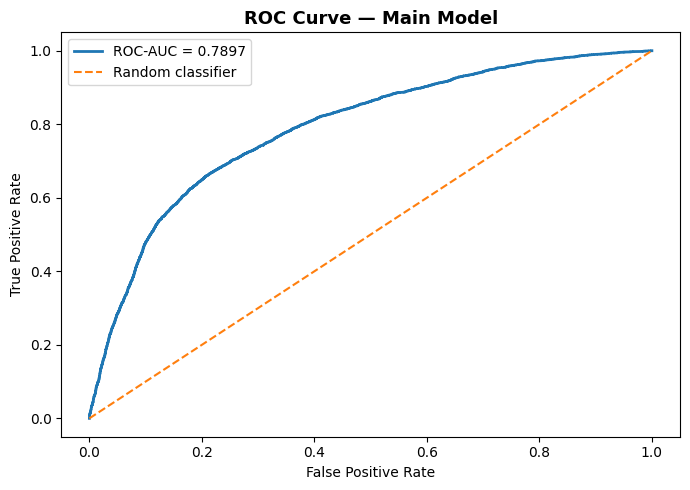

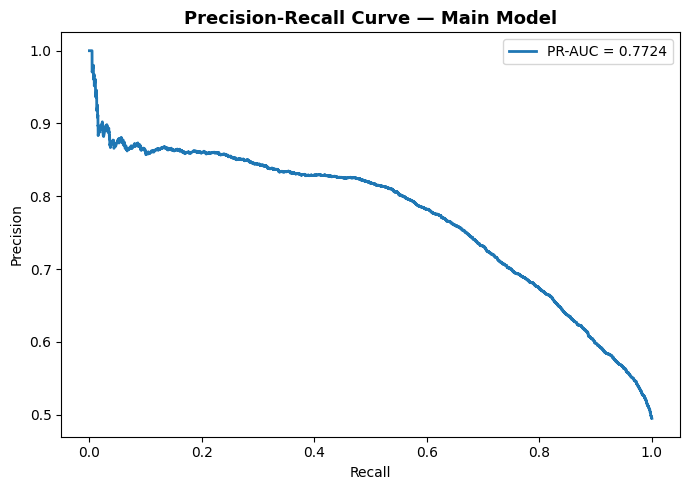

In [20]:
if y_proba is not None and n_classes == 2:
    y_score = y_proba[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc_value = auc(fpr, tpr)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_value:.4f}", linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — Main Model", fontsize=13, weight="bold")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "main_model_roc_curve.png", dpi=200, bbox_inches="tight")
    plt.show()

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc_value = auc(recall, precision)

    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, label=f"PR-AUC = {pr_auc_value:.4f}", linewidth=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve — Main Model", fontsize=13, weight="bold")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "main_model_precision_recall_curve.png", dpi=200, bbox_inches="tight")
    plt.show()

else:
    print("Binary ROC/PR curves are skipped because the task is multiclass or probabilities are unavailable.")

# 19. XAI 1 — Permutation Importance Analysis

Computing permutation importance...


,Feature,Importance_Mean,Importance_Std
0,BP_CHOLESTEROL_INTERACTION,0.037555,0.001769
1,AP_HIGH,0.036838,0.001775
2,CHOLESTEROL,0.007227,0.000851
3,AGE_YEARS,0.003712,0.001078
4,AP_LOW,0.002930,0.001024
5,AGE,0.002882,0.001086
6,PHYSICAL_ACTIVITY,0.002714,0.000533
7,GLUCOSE,0.002656,0.000654
8,SMOKE,0.000997,0.000380
9,GENDER,0.000505,0.000606


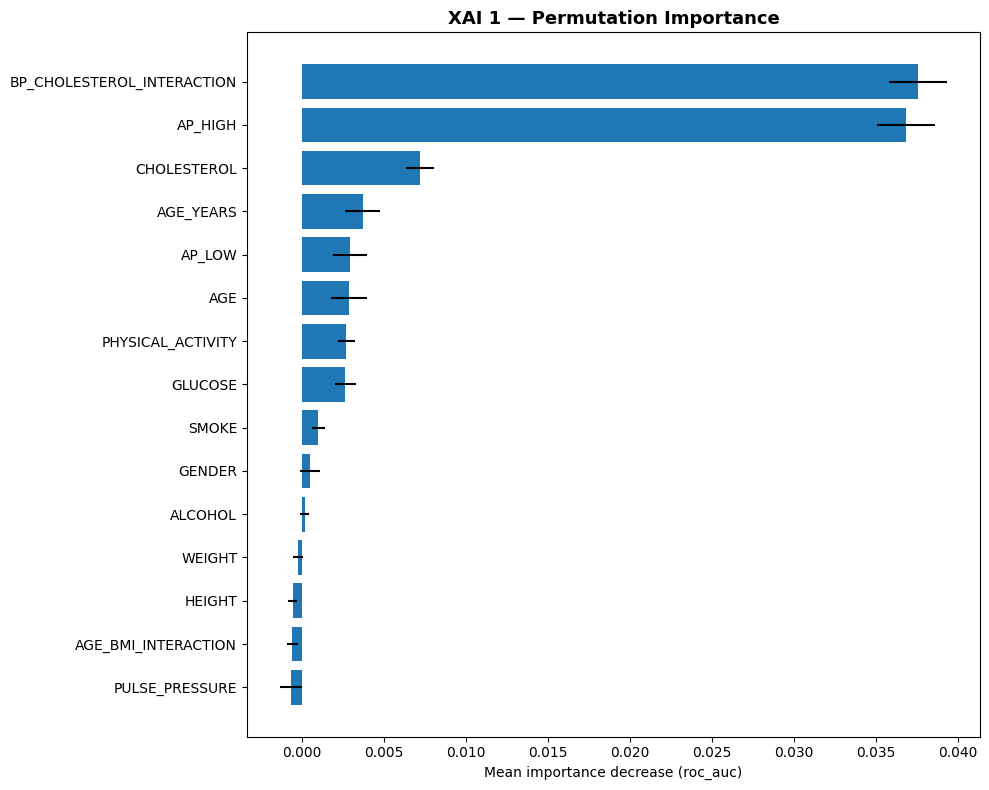

In [21]:
perm_scoring = "roc_auc" if n_classes == 2 else "f1_macro"

print("Computing permutation importance...")
perm = permutation_importance(
    best_model,
    X_test_df,
    y_test,
    n_repeats=10 if not FAST_MODE else 3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring=perm_scoring
)

perm_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Mean": perm.importances_mean,
    "Importance_Std": perm.importances_std
}).sort_values("Importance_Mean", ascending=False).reset_index(drop=True)

display(perm_df.head(20))
perm_df.to_csv(OUTPUT_DIR / "xai_permutation_importance.csv", index=False)

plt.figure(figsize=(10, 8))
top_perm = perm_df.head(15).sort_values("Importance_Mean", ascending=True)
plt.barh(top_perm["Feature"], top_perm["Importance_Mean"], xerr=top_perm["Importance_Std"])
plt.title("XAI 1 — Permutation Importance", fontsize=13, weight="bold")
plt.xlabel(f"Mean importance decrease ({perm_scoring})")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xai_1_permutation_importance.png", dpi=200, bbox_inches="tight")
plt.show()

# 20. XAI 2 — SHAP global and local explanations

Computing SHAP values for 800 test samples...
SHAP values computed.


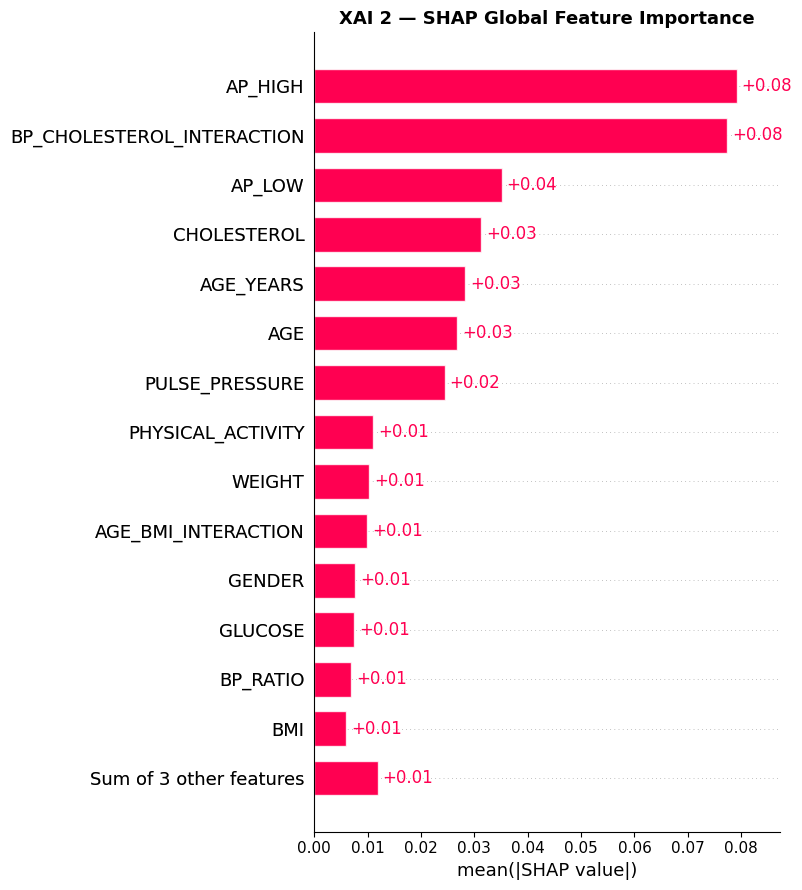

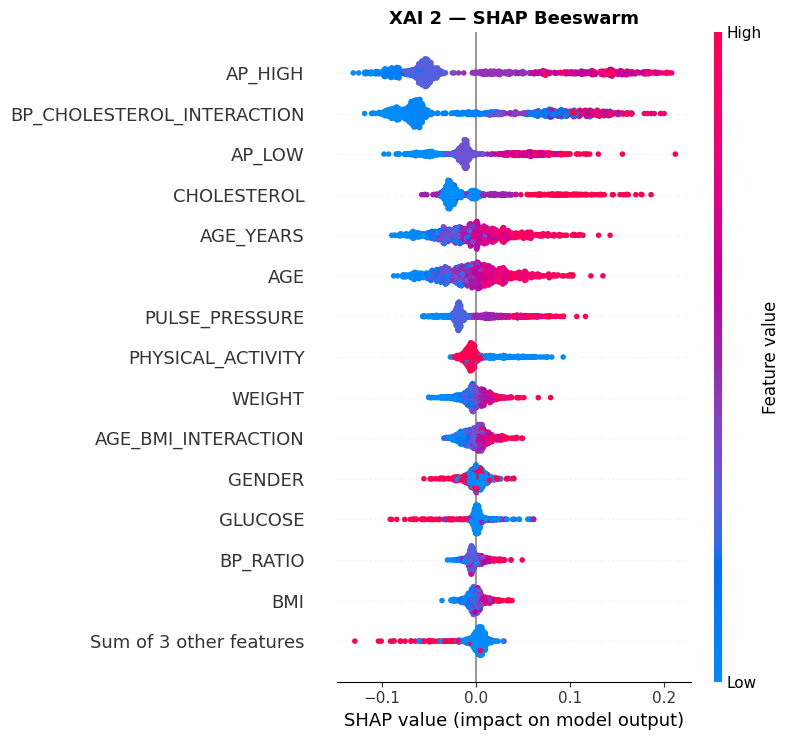

Local SHAP explanation for test sample index: 30207


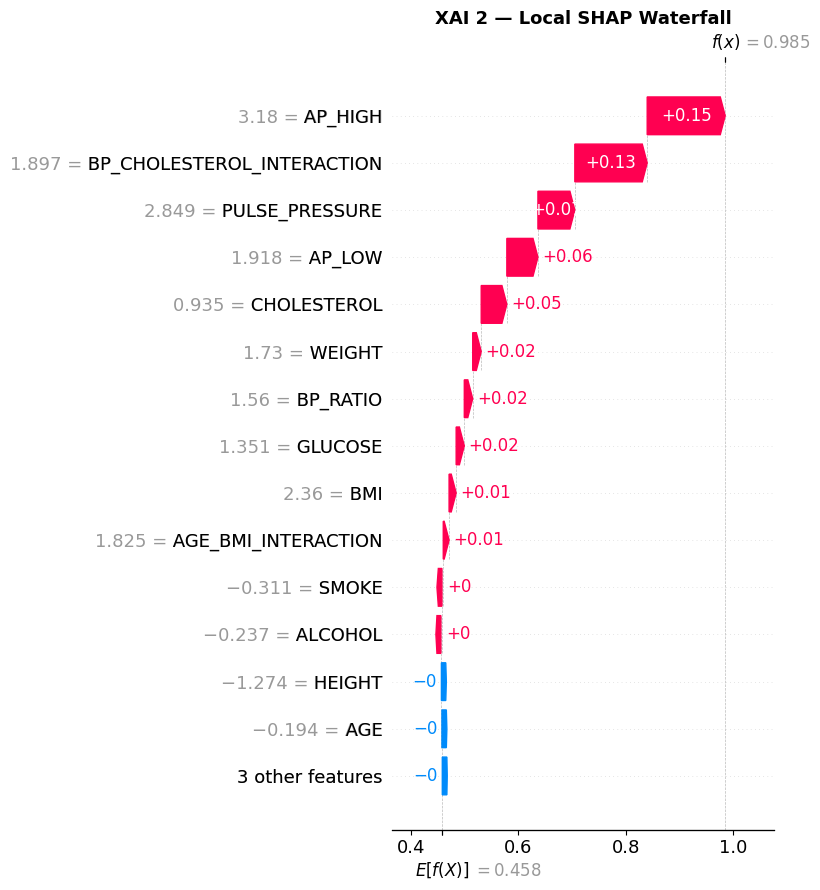

In [22]:
shap.initjs()
shap_sample_size = min(800 if not FAST_MODE else 200, len(X_test_df))
X_shap = X_test_df.sample(n=shap_sample_size, random_state=RANDOM_STATE)

print(f"Computing SHAP values for {len(X_shap)} test samples...")

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_shap)

print("SHAP values computed.")

def get_shap_for_plot(shap_values_obj):
    values = shap_values_obj.values
    base_values = shap_values_obj.base_values

    if values.ndim == 3:
        class_index = 1 if values.shape[2] > 1 else 0
        selected_values = values[:, :, class_index]

        if np.ndim(base_values) == 2:
            selected_base = base_values[:, class_index]
        else:
            selected_base = base_values

        return shap.Explanation(
            values=selected_values,
            base_values=selected_base,
            data=shap_values_obj.data,
            feature_names=shap_values_obj.feature_names
        )

    return shap_values_obj

shap_plot_values = get_shap_for_plot(shap_values)

plt.figure()
shap.plots.bar(shap_plot_values, max_display=15, show=False)
plt.title("XAI 2 — SHAP Global Feature Importance", fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xai_2_shap_global_bar.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
shap.plots.beeswarm(shap_plot_values, max_display=15, show=False)
plt.title("XAI 2 — SHAP Beeswarm", fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xai_2_shap_beeswarm.png", dpi=200, bbox_inches="tight")
plt.show()

if y_proba is not None and n_classes == 2:
    sample_position = int(np.argmax(y_proba[:, 1]))
else:
    sample_position = 0

sample_index = X_test_df.index[sample_position]
print(f"Local SHAP explanation for test sample index: {sample_index}")

X_local = X_test_df.iloc[[sample_position]]
shap_local = get_shap_for_plot(explainer(X_local))

plt.figure()
shap.plots.waterfall(shap_local[0], max_display=15, show=False)
plt.title("XAI 2 — Local SHAP Waterfall", fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xai_2_shap_local_waterfall.png", dpi=200, bbox_inches="tight")
plt.show()

# 21. XAI 3 — LIME local explanations



LIME explanation 1
Test row position: 10201
Predicted class: 1


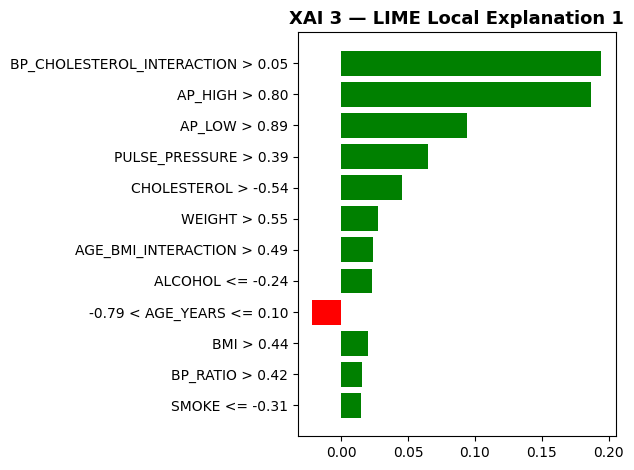


LIME explanation 2
Test row position: 10986
Predicted class: 0


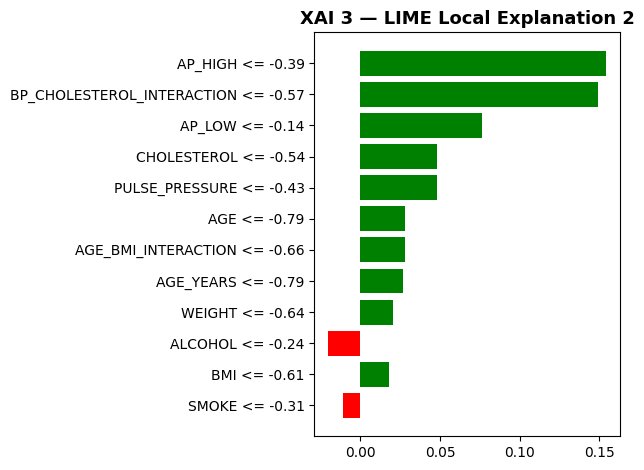

In [23]:
lime_train_size = min(3000 if not FAST_MODE else 1000, len(X_train_main))
X_lime_train = X_train_main.sample(n=lime_train_size, random_state=RANDOM_STATE)

lime_explainer = LimeTabularExplainer(
    training_data=X_lime_train.values,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

if y_proba is not None and n_classes == 2:
    candidate_positions = [
        int(np.argmax(y_proba[:, 1])),
        int(np.argmin(y_proba[:, 1]))
    ]
else:
    candidate_positions = [0, min(1, len(X_test_df) - 1)]

for i, pos in enumerate(candidate_positions, start=1):
    instance = X_test_df.iloc[pos].values
    pred_class = int(best_model.predict(X_test_df.iloc[[pos]])[0])

    exp = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=best_model.predict_proba,
        num_features=min(12, len(feature_names)),
        top_labels=1
    )

    print("\n" + "=" * 90)
    print(f"LIME explanation {i}")
    print(f"Test row position: {pos}")
    print(f"Predicted class: {class_names[pred_class]}")
    print("=" * 90)

    display(HTML(exp.as_html()))

    fig = exp.as_pyplot_figure(label=pred_class)
    plt.title(f"XAI 3 — LIME Local Explanation {i}", fontsize=13, weight="bold")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f"xai_3_lime_local_explanation_{i}.png", dpi=200, bbox_inches="tight")
    plt.show()

    with open(OUTPUT_DIR / f"xai_3_lime_local_explanation_{i}.html", "w", encoding="utf-8") as f:
        f.write(exp.as_html())

# 22. XAI 4 — PDP and ICE plots

Top features selected for PDP/ICE:
['BP_CHOLESTEROL_INTERACTION', 'AP_HIGH', 'CHOLESTEROL', 'AGE_YEARS']


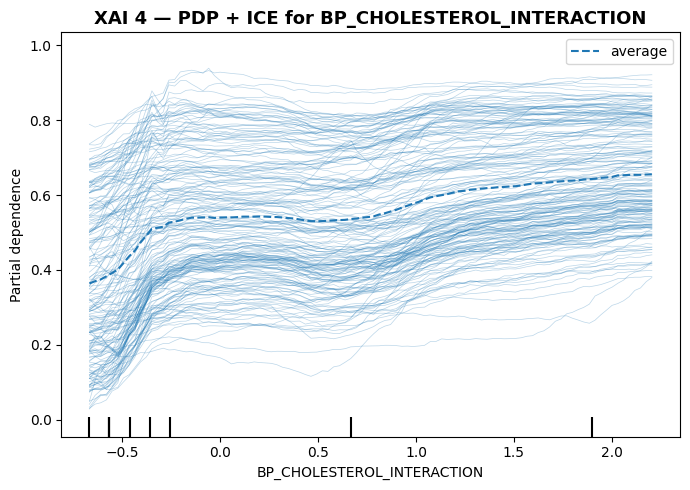

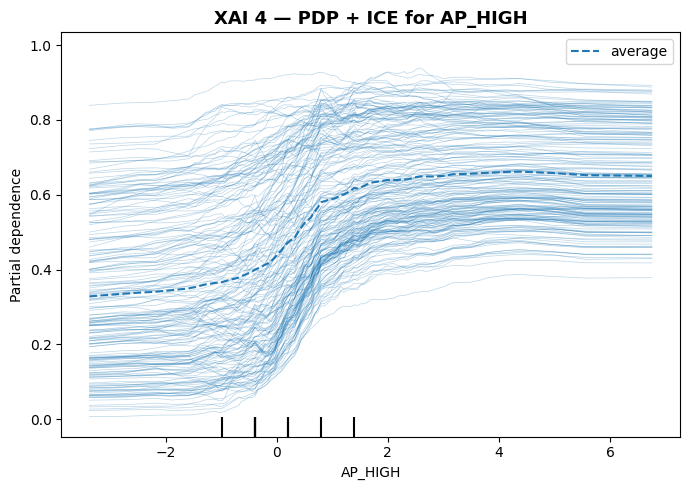

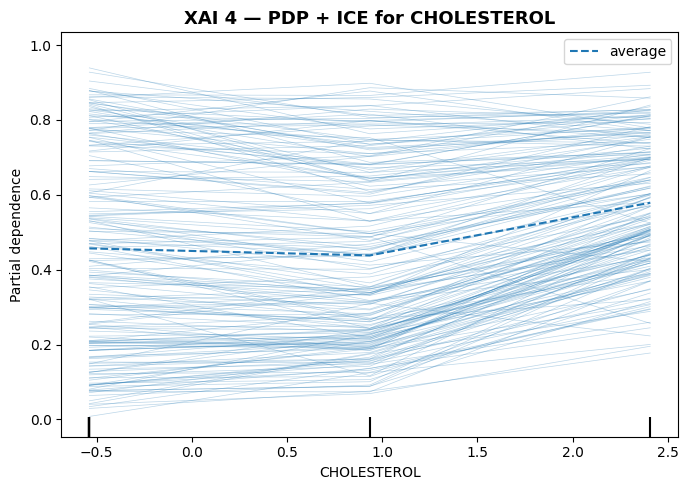

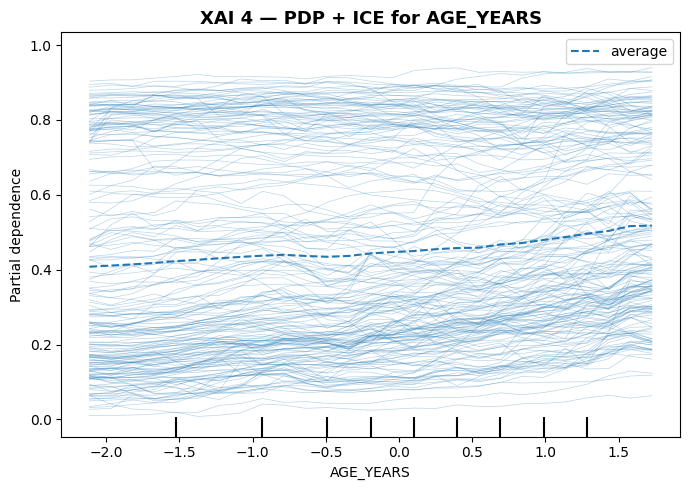

In [24]:
top_features_for_pdp = perm_df["Feature"].head(4).tolist()
top_feature_indices = [feature_names.index(f) for f in top_features_for_pdp if f in feature_names]

print("Top features selected for PDP/ICE:")
print(top_features_for_pdp)

for feature_idx in top_feature_indices:
    feature_name = feature_names[feature_idx]

    fig, ax = plt.subplots(figsize=(7, 5))
    try:
        PartialDependenceDisplay.from_estimator(
            best_model,
            X_test_df,
            features=[feature_idx],
            feature_names=feature_names,
            kind="both",
            subsample=min(200, len(X_test_df)),
            random_state=RANDOM_STATE,
            ax=ax
        )
        plt.title(f"XAI 4 — PDP + ICE for {feature_name}", fontsize=13, weight="bold")
        plt.tight_layout()
        safe_feature_name = re.sub(r"[^A-Za-z0-9_]+", "_", feature_name[:40])
        plt.savefig(OUTPUT_DIR / f"xai_4_pdp_ice_{safe_feature_name}.png", dpi=200, bbox_inches="tight")
        plt.show()
    except Exception as e:
        print(f"Could not create PDP/ICE for {feature_name}: {e}")

# 23. Optional probability calibration and threshold analysis


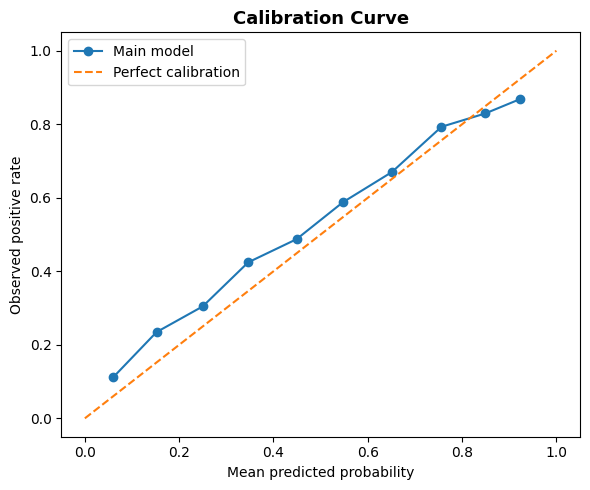

,threshold,sensitivity_recall,specificity,precision,f1
0,0.05,0.993978,0.064182,0.509947,0.674071
1,0.10,0.978848,0.165635,0.534746,0.691645
2,0.15,0.953290,0.273421,0.562440,0.707473
3,0.20,0.913043,0.376025,0.589083,0.716129
4,0.25,0.868390,0.485969,0.623366,0.725755
5,0.30,0.813749,0.598216,0.664906,0.731836
6,0.35,0.763220,0.669017,0.693170,0.726510
7,0.40,0.718126,0.725284,0.719182,0.718654
8,0.45,0.678760,0.770902,0.743763,0.709777
9,0.50,0.636457,0.809469,0.765954,0.695227


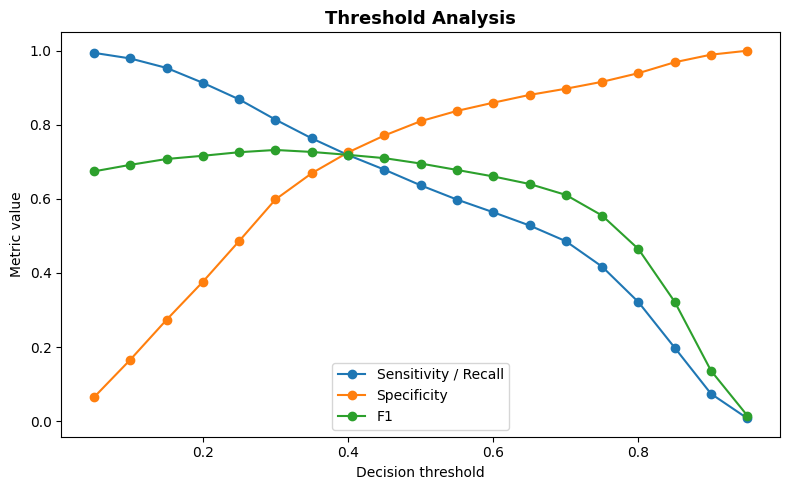

In [25]:
if y_proba is not None and n_classes == 2:
    y_score = y_proba[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, y_score, n_bins=10, strategy="uniform")

    plt.figure(figsize=(6, 5))
    plt.plot(prob_pred, prob_true, marker="o", label="Main model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed positive rate")
    plt.title("Calibration Curve", fontsize=13, weight="bold")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "clinical_utility_calibration_curve.png", dpi=200, bbox_inches="tight")
    plt.show()

    thresholds = np.linspace(0.05, 0.95, 19)
    threshold_rows = []

    for thr in thresholds:
        y_thr = (y_score >= thr).astype(int)
        cm_thr = confusion_matrix(y_test, y_thr, labels=[0, 1])
        tn, fp, fn, tp = cm_thr.ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        precision_v = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        f1_v = f1_score(y_test, y_thr, zero_division=0)

        threshold_rows.append({
            "threshold": thr,
            "sensitivity_recall": sensitivity,
            "specificity": specificity,
            "precision": precision_v,
            "f1": f1_v
        })

    threshold_df = pd.DataFrame(threshold_rows)
    display(threshold_df)

    threshold_df.to_csv(OUTPUT_DIR / "clinical_utility_threshold_analysis.csv", index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(threshold_df["threshold"], threshold_df["sensitivity_recall"], marker="o", label="Sensitivity / Recall")
    plt.plot(threshold_df["threshold"], threshold_df["specificity"], marker="o", label="Specificity")
    plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
    plt.xlabel("Decision threshold")
    plt.ylabel("Metric value")
    plt.title("Threshold Analysis", fontsize=13, weight="bold")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "clinical_utility_threshold_analysis.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("Calibration and threshold analysis are shown only for binary classification.")

# 24. Save model artifacts


In [26]:
model_bundle = {
    "paper": "Talukder et al. (2025) HXAI-ML",
    "data_path": DATA_PATH,
    "target_column": TARGET_COLUMN_CLEAN,
    "preprocessor": preprocessor,
    "label_encoder": label_encoder,
    "feature_names": feature_names,
    "class_names": class_names,
    "balancing_strategy": MAIN_BALANCING_STRATEGY,
    "model_name": MAIN_MODEL_NAME,
    "model": best_model,
    "best_params": random_search.best_params_,
    "final_metrics": final_metrics
}

model_path = OUTPUT_DIR / "talukder_2025_hxai_ml_ro_tl_extra_trees_model.joblib"
joblib.dump(model_bundle, model_path)

print(f"Saved model bundle to: {model_path}")

summary = {
    "paper": model_bundle["paper"],
    "data_path": str(DATA_PATH),
    "target_column": TARGET_COLUMN_CLEAN,
    "rows": int(df_model.shape[0]),
    "original_features": int(X.shape[1]),
    "processed_features": int(len(feature_names)),
    "class_names": class_names,
    "balancing_strategy": MAIN_BALANCING_STRATEGY,
    "model_name": MAIN_MODEL_NAME,
    "best_params": random_search.best_params_,
    "final_metrics": {k: float(v) if np.isscalar(v) and pd.notna(v) else str(v) for k, v in final_metrics.items()}
}

with open(OUTPUT_DIR / "run_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4)

print(f"Saved run summary to: {OUTPUT_DIR / 'run_summary.json'}")

Saved model bundle to: talukder_2025_outputs/talukder_2025_hxai_ml_ro_tl_extra_trees_model.joblib
Saved run summary to: talukder_2025_outputs/run_summary.json
